In [1]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.pyplot
import matplotlib.cm
import math
import sys
import csv
from scipy import integrate
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
# load 22 GeV generated and reconstructed .csv files 
sim_gen_22GeV = pd.read_csv("/Users/aosmond/nuclearPhys/csv/finished_csv/22GeV/pass2noBG/22gen_excl_pass2noBG_jlab_12_02_2024.csv", index_col=False)
sim_gen_22GeV = sim_gen_22GeV[(sim_gen_22GeV.weight>0.0)]

sim_rec_22GeV = pd.read_csv("/Users/aosmond/nuclearPhys/csv/finished_csv/22GeV/pass2noBG/22rec_excl_pass2noBG_jlab_12_02_2024.csv",  index_col=False)
sim_rec_22GeV = sim_rec_22GeV[(sim_rec_22GeV.weight>0.0)]

In [3]:
sim_gen_22GeV.head(21)

,event,w_mc,q2_mc,weight
0,0,1.349250,29.704400,2.000000e-10
1,1,2.019514,27.738320,7.400000e-09
2,2,1.817592,10.854850,1.969500e-06
3,3,1.618927,29.506310,2.000000e-10
4,4,1.975277,21.374750,3.594000e-07
5,5,1.992009,25.040570,1.230000e-08
6,6,2.193395,25.968690,4.400000e-09
7,7,1.701921,23.983470,1.350000e-08
8,8,2.074162,4.488887,5.270990e-05
9,9,1.554406,2.812234,1.787825e-04


In [4]:
sim_gen_22GeV.tail(3)

,event,w_mc,q2_mc,weight
103209997,103209997,2.315532,11.86184,1.896100e-06
103209998,103209998,2.264531,22.39708,9.490000e-08
103209999,103209999,1.688475,10.95241,3.399000e-07


In [5]:
sim_rec_22GeV.head(3)

,event,w,q2,weight
0,20,2.438298,16.82789,6.160000e-08
1,46,2.202664,10.57862,1.596400e-06
2,59,2.228687,21.20477,1.330000e-08


In [6]:
sim_rec_22GeV.tail(3)

,event,w,q2,weight
5637829,103209968,2.161918,7.060266,1.131300e-05
5637830,103209971,1.440178,24.003180,3.100000e-09
5637831,103209997,2.321990,11.807600,1.896100e-06


In [7]:
# remove event colummn now
sim_gen_22GeV.drop(columns=['event'], inplace=True, errors='ignore')
sim_rec_22GeV.drop(columns=['event'], inplace=True, errors='ignore')

In [8]:
# find number of generated events in each w-q2 bin from 22.0 GeV simulations
def calcFunc(df):
    gen = df

    # Open the output CSV file for writing
    with open('output_22_gen.csv', mode='w') as out_file:
        out_binned_exclusive_writer = csv.writer(out_file, delimiter=',', quotechar='"', quoting=csv.QUOTE_MINIMAL)
        out_binned_exclusive_writer.writerow(['w_val','q2_val','gen_events','flux','weight','cross_section',
                                              'formfactor','cs_scaled'])
        
        NSIGMA = 4
        cut_data = {}
        
        # List of w bins
        w_bin_ranges = np.arange(1.4, 2.5, 0.05)
        
        # Cuts the generated w data into the ranges from above
        gen['w_bin'] = pd.cut(gen.w_mc, w_bin_ranges)
        # unique_w = gen.w_bin.unique()
        # unique_w = pd.Index.sort_values(unique_w)
        # unique_w = unique_w.dropna()
        unique_w = gen['w_bin'].cat.categories

        # Make q2 bins 
        q2_bin_ranges = [2.0,2.4,3.0,3.5,4.2,5.0,6.0,7.0,8.0,9.0,11.0,13.0,15.0,18.0,21.0,25.0,30.0]
        
        # Cuts the gen q2 data into the ranges from above
        gen['q2_bin'] = pd.cut(gen.q2_mc, q2_bin_ranges)
        # unique_q2 = gen.q2_bin.unique()
        # unique_q2 = pd.Index.sort_values(unique_q2)
        # unique_q2 = unique_q2.dropna()
        unique_q2 = gen['q2_bin'].cat.categories
        
        # Function to calculate virtual photon flux
        def flux(w, q2_value):
            E_beam = 22.0
            MASS_P = 0.938
            PI = 3.14159265358979323846

            omega = (w * w + q2_value - MASS_P * MASS_P) / (2. * MASS_P)

            en_elp = E_beam - omega
            th_elp = 2 * math.asin(math.sqrt(q2_value / 4. / E_beam / en_elp))

            epsilon = 1 / (1. + 2. * (1. + omega * omega / q2_value) * (math.tan(th_elp / 2.)) * (math.tan(th_elp / 2.)))

            flux_calc = (omega - q2_value / 2. / MASS_P) / 137.
            flux_calc = flux_calc / 2. / (PI) / E_beam / q2_value / (1 - epsilon)
            flux_calc = flux_calc * w / E_beam / MASS_P

            return flux_calc
             
        # Go through each w-q2 bin
        for w in unique_w:
            for q2 in unique_q2:
                data = gen[(gen.w_bin == w) & (gen.q2_bin == q2)]
                w_val = (w.right + w.left) / 2.0
                q2_val = (q2.right + q2.left) / 2.0
                virtual_flux = flux(w_val, q2_val)
                ff_scale = (1 / (1 + (q2_val / 0.7))**0.31660) / ((1 / (1 + 0.65 / 0.7))**1.18085)
                index = data.index
                number_of_rows = len(index) 
                weight_sum = data['weight'].sum()
                cs = weight_sum / (number_of_rows * virtual_flux)
                cs_scaled = cs * ff_scale
                
                # Write each event with its corresponding values
#                 for i, row in data.iterrows():
#                     event = row['event']
                out_binned_exclusive_writer.writerow([w_val, q2_val, number_of_rows, 
                                                          "{:.5f}".format(virtual_flux), 
                                                          "{:.5f}".format(weight_sum), 
                                                          "{:.5f}".format(cs), 
                                                          "{:.5f}".format(ff_scale), 
                                                          "{:.5f}".format(cs_scaled)])
                    
                # Print to verify
                print(w_val, ",", q2_val, ",", "{:.7f}".format(virtual_flux), ",", number_of_rows, ",", 
                      "{:.5f}".format(weight_sum), ",", "{:.5f}".format(cs), ",", "{:.5f}".format(ff_scale), ",", 
                      "{:.5f}".format(cs_scaled))

    return cut_data


In [9]:
# calculations for 22.0 GeV generated events
my_output = calcFunc(sim_gen_22GeV)

1.4249999999999998 , 2.2 , 0.0001686 , 57010 , 17.01572 , 1.77057 , 1.38479 , 2.45187
1.4249999999999998 , 2.7 , 0.0001058 , 85119 , 11.32335 , 1.25688 , 1.31678 , 1.65504
1.4249999999999998 , 3.25 , 0.0000686 , 71471 , 4.22624 , 0.86251 , 1.25573 , 1.08308
1.4249999999999998 , 3.85 , 0.0000456 , 99427 , 2.83176 , 0.62469 , 1.20075 , 0.75009
1.4249999999999998 , 4.6 , 0.0000293 , 113801 , 1.46519 , 0.43868 , 1.14412 , 0.50191
1.4249999999999998 , 5.5 , 0.0000186 , 142417 , 0.80015 , 0.30171 , 1.08870 , 0.32847
1.4249999999999998 , 6.5 , 0.0000120 , 142011 , 0.35778 , 0.20948 , 1.03836 , 0.21752
1.4249999999999998 , 7.5 , 0.0000082 , 142281 , 0.17949 , 0.15399 , 0.99647 , 0.15345
1.4249999999999998 , 8.5 , 0.0000058 , 141941 , 0.09601 , 0.11636 , 0.96082 , 0.11180
1.4249999999999998 , 10.0 , 0.0000037 , 283532 , 0.08836 , 0.08457 , 0.91596 , 0.07746
1.4249999999999998 , 12.0 , 0.0000022 , 283453 , 0.03454 , 0.05593 , 0.86759 , 0.04852
1.4249999999999998 , 14.0 , 0.0000014 , 284534 , 0.0

In [13]:
# find number of reconstructed events in each w-q2 bin from 22.0 GeV simulations
def calcFunc(df):
    rec = df

    # Open the output CSV file for writing
    with open('output_22_rec.csv', mode='w') as out_file:
        out_binned_exclusive_writer = csv.writer(out_file, delimiter=',', quotechar='"', quoting=csv.QUOTE_MINIMAL)
        # Update the CSV header to only contain 'event', 'rec_events', and 'weight_rec'
        out_binned_exclusive_writer.writerow(['w_val_rec','q2_val_rec','rec_events','weight_rec'])
        
        NSIGMA = 4
        cut_data = {}
        
        # List of w bins
        w_bin_ranges = np.arange(1.4, 2.5, 0.05)
        
        # Cuts the reconstructed w data into the ranges from above
        rec['w_bin_rec'] = pd.cut(rec.w, w_bin_ranges)
        # unique_w_rec = rec.w_bin_rec.unique()
        # unique_w_rec = pd.Index.sort_values(unique_w_rec)
        # unique_w_rec = unique_w_rec.dropna()
        unique_w_rec = rec['w_bin_rec'].cat.categories

        # Make q2 bins 
        q2_bin_ranges = [2.0,2.4,3.0,3.5,4.2,5.0,6.0,7.0,8.0,9.0,11.0,13.0,15.0,18.0,21.0,25.0,30.0]
        
        # Cuts the rec q2 data into the ranges from above
        rec['q2_bin_rec'] = pd.cut(rec.q2, q2_bin_ranges)
        # unique_q2_rec = rec.q2_bin_rec.unique()
        # unique_q2_rec = pd.Index.sort_values(unique_q2_rec)
        # unique_q2_rec = unique_q2_rec.dropna()
        unique_q2_rec = rec['q2_bin_rec'].cat.categories

        # Go through each w-q2 bin
        for w_rec in unique_w_rec:
            for q2_rec in unique_q2_rec:
                data_rec = rec[(rec.w_bin_rec == w_rec) & (rec.q2_bin_rec == q2_rec)]
                
                # Check if there is any data in the current bin
                if not data_rec.empty:
                    w_val_rec = (w_rec.right + w_rec.left) / 2.0
                    q2_val_rec = (q2_rec.right + q2_rec.left) / 2.0
                    index_rec = data_rec.index
                    number_of_rows_rec = len(index_rec) 
                    weight_sum_rec = data_rec['weight'].sum()

                    out_binned_exclusive_writer.writerow([w_val_rec, q2_val_rec, number_of_rows_rec, "{:.5f}".format(weight_sum_rec)])

                    # Print to verify (moved inside the loop)
                    print(w_val_rec, q2_val_rec, number_of_rows_rec, weight_sum_rec)

    return cut_data


In [14]:
# calculation for 22.0 GeV reconstructed
my_output_rec = calcFunc(sim_rec_22GeV)

1.4249999999999998 3.85 332 0.016040334910000002
1.4249999999999998 4.6 1518 0.030658900227199998
1.4249999999999998 5.5 3979 0.033921651596590004
1.4249999999999998 6.5 6248 0.022886295998401
1.4249999999999998 7.5 7740 0.012333032905321
1.4249999999999998 8.5 9363 0.007117322197311
1.4249999999999998 10.0 22543 0.007680880000824999
1.4249999999999998 12.0 25304 0.003772284600236
1.4249999999999998 14.0 23998 0.0016340578998909998
1.4249999999999998 16.5 29360 0.000978523200104
1.4249999999999998 19.5 21396 0.00034288470003
1.4249999999999998 23.0 15938 0.000132035600043
1.4249999999999998 27.5 6062 4.0402700021000005e-05
1.475 3.25 1 1.9587e-06
1.475 3.85 395 0.022805174502
1.475 4.6 1713 0.0454392544079
1.475 5.5 4509 0.05610610891921
1.475 6.5 6967 0.03631282138982
1.475 7.5 8651 0.019426647808790998
1.475 8.5 10552 0.011903371001922
1.475 10.0 24982 0.0129354503968
1.475 12.0 27519 0.006017800598656
1.475 14.0 26201 0.002613147600835
1.475 16.5 32348 0.001518122300034
1.475 19.5 2

In [15]:
# load the gen and rec csv files
gen_csv = pd.read_csv('output_22_gen.csv')
rec_csv = pd.read_csv('output_22_rec.csv')

# rename the 'w_val_rec' and 'q2_val_rec' column in rec_csv to 'w_val' and 'q2_val'
rec_csv.rename(columns={'w_val_rec': 'w_val'}, inplace=True)
rec_csv.rename(columns={'q2_val_rec': 'q2_val'}, inplace=True)

In [16]:
# Perform an inner merge on 'w' and 'q2' to keep only the common values
combined_data = pd.merge(gen_csv, rec_csv, on=['w_val', 'q2_val'], suffixes=('_gen', '_rec'))


# column order can be adjusted as needed
combined_data = combined_data[['w_val','q2_val','gen_events',
                               'weight','rec_events','weight_rec','flux','cross_section','formfactor',
                               'cs_scaled']]

# save the combined DataFrame to a new csv file
combined_data.to_csv('output_22_combined.csv', index=False)

# load the csv file created above to inspect the combined data
output_22_combined = pd.read_csv('output_22_combined.csv')

# display the first few rows to verify the results
print(output_22_combined.head(10))


   w_val  q2_val  gen_events   weight  rec_events  weight_rec     flux  \
0  1.425    3.85       99427  2.83176         332     0.01604  0.00005   
1  1.425    4.60      113801  1.46519        1518     0.03066  0.00003   
2  1.425    5.50      142417  0.80015        3979     0.03392  0.00002   
3  1.425    6.50      142011  0.35778        6248     0.02289  0.00001   
4  1.425    7.50      142281  0.17949        7740     0.01233  0.00001   
5  1.425    8.50      141941  0.09601        9363     0.00712  0.00001   
6  1.425   10.00      283532  0.08836       22543     0.00768  0.00000   
7  1.425   12.00      283453  0.03454       25304     0.00377  0.00000   
8  1.425   14.00      284534  0.01551       23998     0.00163  0.00000   
9  1.425   16.50      425762  0.01001       29360     0.00098  0.00000   

   cross_section  formfactor  cs_scaled  
0        0.62469     1.20075    0.75009  
1        0.43868     1.14412    0.50191  
2        0.30171     1.08870    0.32847  
3        0.20948 

In [17]:
# do some math with the current columns to build the other columns and create a new csv to make the hists
for index, row in output_22_combined.iterrows():
    gen_events = row['gen_events']
    rec_events = row['rec_events']
    weight_gen_sum = row['weight']
    weight_rec_sum = row['weight_rec']
    cs_scaled = row['cs_scaled']

    # Perform calculations
    acceptance = weight_rec_sum / weight_gen_sum if weight_gen_sum > 0 else 0
    acceptance_no_wt = rec_events / gen_events if gen_events > 0 else 0
    luminosity_had = 2E+33 / (acceptance * cs_scaled) if acceptance * cs_scaled != 0 else 0
    q_had = luminosity_had / (1.3241 * 10**42)
    elec_cs = weight_gen_sum / gen_events if gen_events > 0 else 0
    lumi_elec = 2E+33 / (elec_cs * acceptance) if elec_cs * acceptance != 0 else 0
    q_elec = lumi_elec / (1.324 * 1E+42)
    no_of_sec_45nA = q_elec / 0.000000045
    no_year_45nA = no_of_sec_45nA / 31536000

    # Add new columns to DataFrame
    output_22_combined.at[index, 'acceptance'] = acceptance
    output_22_combined.at[index, 'acceptance_no_wt'] = acceptance_no_wt
    output_22_combined.at[index, 'luminosity_had'] = luminosity_had
    output_22_combined.at[index, 'q_had'] = q_had
    output_22_combined.at[index, 'elec_cs'] = elec_cs
    output_22_combined.at[index, 'lumi_elec'] = lumi_elec
    output_22_combined.at[index, 'q_elec'] = q_elec
    output_22_combined.at[index, 'no_of_sec_45nA'] = no_of_sec_45nA
    output_22_combined.at[index, 'no_year_45nA'] = no_year_45nA

# Save the updated DataFrame to a new CSV file
output_22_combined.to_csv('combined_22.csv', index=False)

# load the csv file created above to make following hists
hist_22_gev_sim=pd.read_csv('combined_22.csv',index_col=False)
hist_22_gev_sim.head()


,w_val,q2_val,gen_events,weight,rec_events,weight_rec,flux,cross_section,formfactor,cs_scaled,acceptance,acceptance_no_wt,luminosity_had,q_had,elec_cs,lumi_elec,q_elec,no_of_sec_45nA,no_year_45nA
0,1.425,3.85,99427,2.83176,332,0.01604,0.00005,0.62469,1.20075,0.75009,0.005664,0.003339,4.707266e+35,3.555068e-07,0.000028,1.239738e+40,0.009364,208079.582849,0.006598
1,1.425,4.60,113801,1.46519,1518,0.03066,0.00003,0.43868,1.14412,0.50191,0.020926,0.013339,1.904259e+35,1.438153e-07,0.000013,7.423418e+39,0.005607,124595.806216,0.003951
2,1.425,5.50,142417,0.80015,3979,0.03392,0.00002,0.30171,1.08870,0.32847,0.042392,0.027939,1.436316e+35,1.084749e-07,0.000006,8.397229e+39,0.006342,140940.395663,0.004469
3,1.425,6.50,142011,0.35778,6248,0.02289,0.00001,0.20948,1.03836,0.21752,0.063978,0.043997,1.437147e+35,1.085376e-07,0.000003,1.240813e+40,0.009372,208259.916400,0.006604
4,1.425,7.50,142281,0.17949,7740,0.01233,0.00001,0.15399,0.99647,0.15345,0.068695,0.054399,1.897319e+35,1.432912e-07,0.000001,2.307883e+40,0.017431,387358.712937,0.012283


In [18]:
total_rows = hist_22_gev_sim.shape[0]
print("Number of rows in combined_22.csv : ", total_rows)

Number of rows in combined_22.csv :  280


/var/folders/wd/z4b9mvxs2xb0v8hc2svy1l580000gp/T/ipykernel_42609/1172104722.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  bins=[bin_x, bin_y],cmap=plt.cm.get_cmap('viridis'), density=False,
/var/folders/wd/z4b9mvxs2xb0v8hc2svy1l580000gp/T/ipykernel_42609/1172104722.py:43: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  bins=[bin_x, bin_y],cmap=plt.cm.get_cmap('viridis'), density=False,


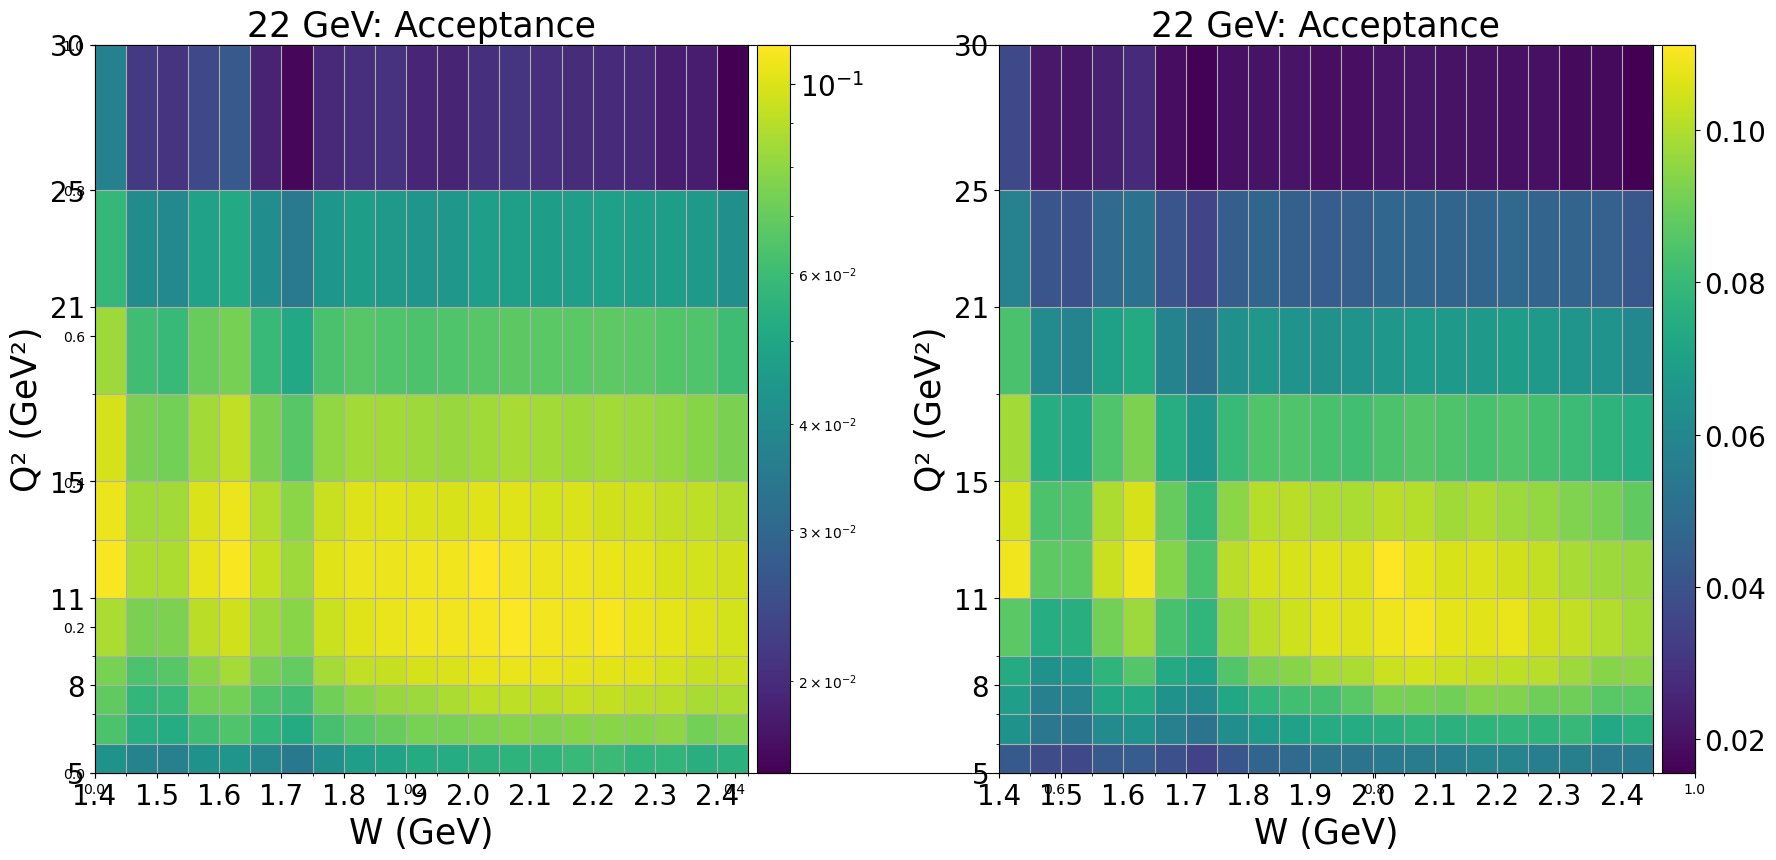

In [19]:
# find Acceptance ratio: 22 GeV
fig, ax = plt.subplots(figsize =(20,9))
ax=plt.subplot(1, 2, 1) # row 1, col 2 index 1

# Creating plot
bin_x=np.arange(1.4,2.5, 0.05)
bin_y=[5.0,6.0,7.0,8.0,9.0,11.0,13.0,15.0,18.0,21.0,25.0,30.0]
matplotlib.pyplot.hist2d(hist_22_gev_sim.w_val.to_numpy(),hist_22_gev_sim.q2_val.to_numpy(),
                         bins=[bin_x, bin_y],cmap=plt.cm.get_cmap('viridis'), density=False,
                         cmin =0,norm=mpl.colors.LogNorm(), weights=hist_22_gev_sim.acceptance)

# show plot
plt.tight_layout() 
plt.title('22 GeV: Acceptance',fontsize=25)
plt.xlabel('W (GeV)',fontsize=25)
plt.ylabel('Q\N{SUPERSCRIPT TWO} (GeV\N{SUPERSCRIPT TWO})',fontsize=25)

# Adding color bar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.09)
plt.colorbar(cax=cax)
plt.tick_params(labelsize=20);
major_ticks = np.arange(1.4,2.5, 0.1)
minor_ticks = np.arange(1.4,2.5, 0.05)
ax.set_xticks(major_ticks)
ax.set_xticks(minor_ticks, minor=True)
major_ticks = [5.0,8.0,11.0,15.0,21.0,25.0,30.0]
minor_ticks = [5.0,6.0,7.0,8.0,9.0,11.0,13.0,15.0,18.0,21.0,25.0,30.0]
ax.set_yticks(major_ticks)
ax.set_yticks(minor_ticks, minor=True)

# And a corresponding grid
ax.grid(which='both')
ax.tick_params(axis='both', which='major', labelsize=20)

# Acceptance ratio
ax=plt.subplot(1, 2, 2) # row 1, col 2 index 1

# Creating plot
bin_x=np.arange(1.4,2.5, 0.05)
bin_y=[5.0,6.0,7.0,8.0,9.0,11.0,13.0,15.0,18.0,21.0,25.0,30.0]
matplotlib.pyplot.hist2d(hist_22_gev_sim.w_val.to_numpy(),hist_22_gev_sim.q2_val.to_numpy(),
                         bins=[bin_x, bin_y],cmap=plt.cm.get_cmap('viridis'), density=False,
                         cmin =0, weights=hist_22_gev_sim.acceptance)
  
# show plot
plt.tight_layout() 
plt.title('22 GeV: Acceptance',fontsize=25)
plt.xlabel('W (GeV)',fontsize=25)
plt.ylabel('Q\N{SUPERSCRIPT TWO} (GeV\N{SUPERSCRIPT TWO})',fontsize=25)

# Adding color bar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.09)
plt.colorbar(cax=cax)
plt.tick_params(labelsize=20);
major_ticks = np.arange(1.4,2.5, 0.1)
minor_ticks = np.arange(1.4,2.5, 0.05)
ax.set_xticks(major_ticks)
ax.set_xticks(minor_ticks, minor=True)
major_ticks = [5.0,8.0,11.0,15.0,21.0,25.0,30.0]
minor_ticks = [5.0,6.0,7.0,8.0,9.0,11.0,13.0,15.0,18.0,21.0,25.0,30.0]
ax.set_yticks(major_ticks)
ax.set_yticks(minor_ticks, minor=True)

# And a corresponding grid
ax.grid(which='both')
ax.tick_params(axis='both', which='major', labelsize=20)
plt.subplots_adjust(left=0.1,
                    right=0.9, 
                    wspace=0.3, 
                    hspace=0.2)

plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\m'
/var/folders/wd/z4b9mvxs2xb0v8hc2svy1l580000gp/T/ipykernel_42609/441878862.py:14: SyntaxWarning: invalid escape sequence '\m'
  plt.title('22 GeV: Integrated Hadronic Cross-Section ($\mu$b)',fontsize=25)
/var/folders/wd/z4b9mvxs2xb0v8hc2svy1l580000gp/T/ipykernel_42609/441878862.py:44: SyntaxWarning: invalid escape sequence '\m'
  plt.title('22 GeV: Integrated Hadronic Cross-Section ($\mu$b)',fontsize=25)
/var/folders/wd/z4b9mvxs2xb0v8hc2svy1l580000gp/T/ipykernel_42609/441878862.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  bins=[bin_x, bin_y],cmap=plt.cm.get_cmap('viridis'), density=False,


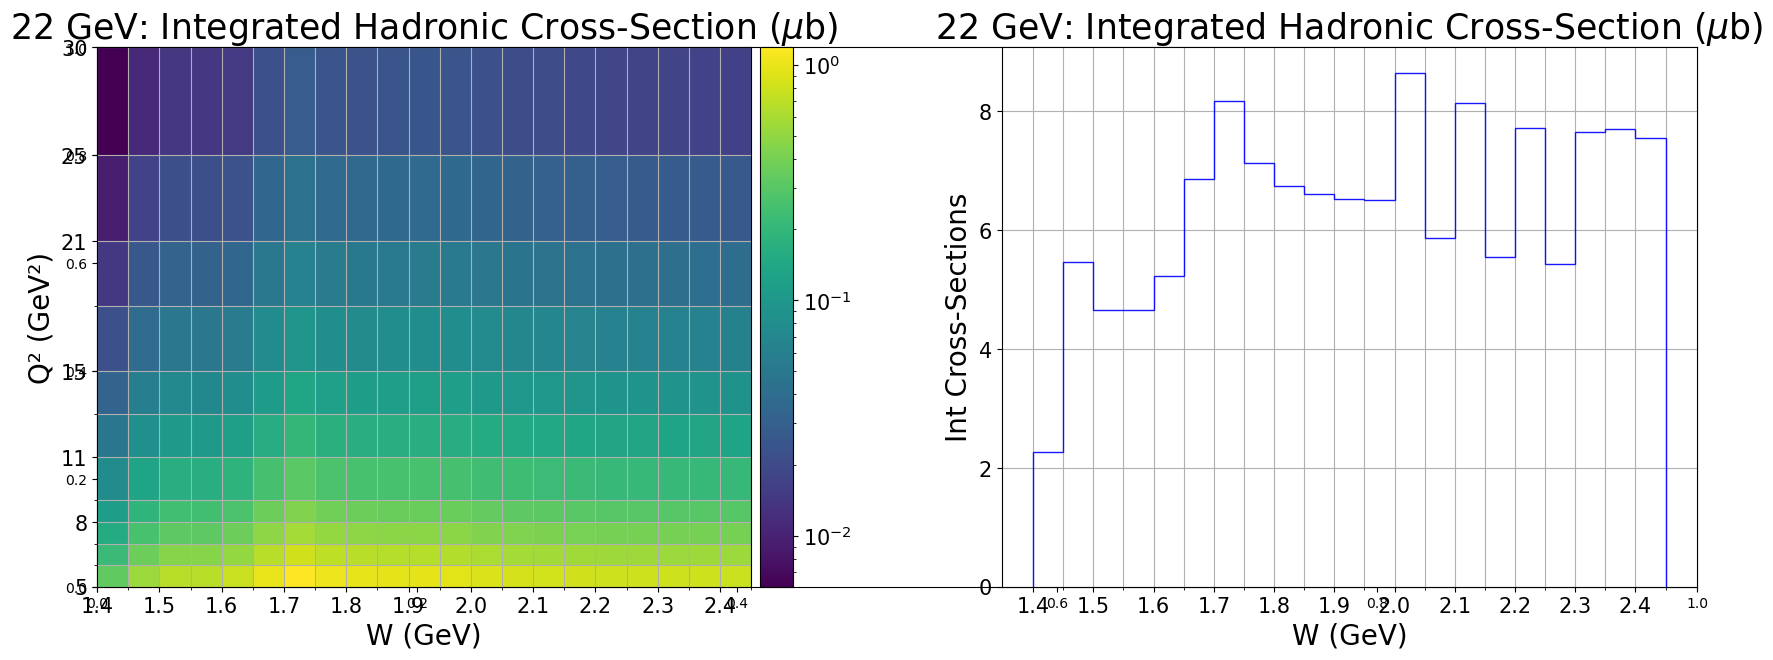

In [20]:
# find integrated cross-sections: 22 GeV
fig, ax = plt.subplots(figsize =(20, 7))
ax=plt.subplot(1, 2, 1) # row 1, col 2 index 1

# Creating plot
bin_x=np.arange(1.4,2.5, 0.05)
bin_y=[5.0,6.0,7.0,8.0,9.0,11.0,13.0,15.0,18.0,21.0,25.0,30.0]
matplotlib.pyplot.hist2d(hist_22_gev_sim.w_val.to_numpy(),hist_22_gev_sim.q2_val.to_numpy(),
                         bins=[bin_x, bin_y],cmap=plt.cm.get_cmap('viridis'), density=False,
                         cmin =0,norm=mpl.colors.LogNorm(), weights=hist_22_gev_sim.cs_scaled)
  
# show plot
plt.tight_layout() 
plt.title('22 GeV: Integrated Hadronic Cross-Section ($\mu$b)',fontsize=25)
plt.xlabel('W (GeV)',fontsize=20)
plt.ylabel('Q\N{SUPERSCRIPT TWO} (GeV\N{SUPERSCRIPT TWO})',fontsize=20)

# Adding color bar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.09)
plt.colorbar(cax=cax)
plt.tick_params(labelsize=15);
major_ticks = np.arange(1.4,2.5, 0.1)
minor_ticks = np.arange(1.4,2.5, 0.05)
ax.set_xticks(major_ticks)
ax.set_xticks(minor_ticks, minor=True)
major_ticks = [5.0,8.0,11.0,15.0,21.0,25.0,30.0]
minor_ticks = [5.0,6.0,7.0,8.0,9.0,11.0,13.0,15.0,18.0,21.0,25.0,30.0]
ax.set_yticks(major_ticks)
ax.set_yticks(minor_ticks, minor=True)

# And a corresponding grid
ax.grid(which='both')
ax.tick_params(axis='both', which='major', labelsize=15)
ax=plt.subplot(1, 2, 2) # row 1, col 2 index 1

# Creating plot
bin_x=np.arange(1.4,2.5, 0.05)
ax.hist(hist_22_gev_sim.w_val.to_numpy(),range=(1.4,2.5),bins=bin_x, density=False,  
        weights=hist_22_gev_sim.cs_scaled, alpha=0.9, color='b',histtype=u'step',label='cross-section')

# show plot
plt.tight_layout() 
plt.title('22 GeV: Integrated Hadronic Cross-Section ($\mu$b)',fontsize=25)
plt.xlabel('W (GeV)',fontsize=20)
plt.ylabel('Int Cross-Sections',fontsize=20)
plt.tick_params(labelsize=15);
major_ticks = np.arange(1.4,2.5, 0.1)
minor_ticks = np.arange(1.4,2.5, 0.05)
ax.set_xticks(major_ticks)
ax.set_xticks(minor_ticks, minor=True)

# And a corresponding grid
ax.grid(which='both')
ax.tick_params(axis='both', which='major', labelsize=15)
plt.subplots_adjust(left=0.1,right=0.9,wspace=0.3,hspace=0.2)

plt.show()

/var/folders/wd/z4b9mvxs2xb0v8hc2svy1l580000gp/T/ipykernel_42609/3448713669.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  bins=[bin_x, bin_y],cmap=plt.cm.get_cmap('viridis'), density=False,


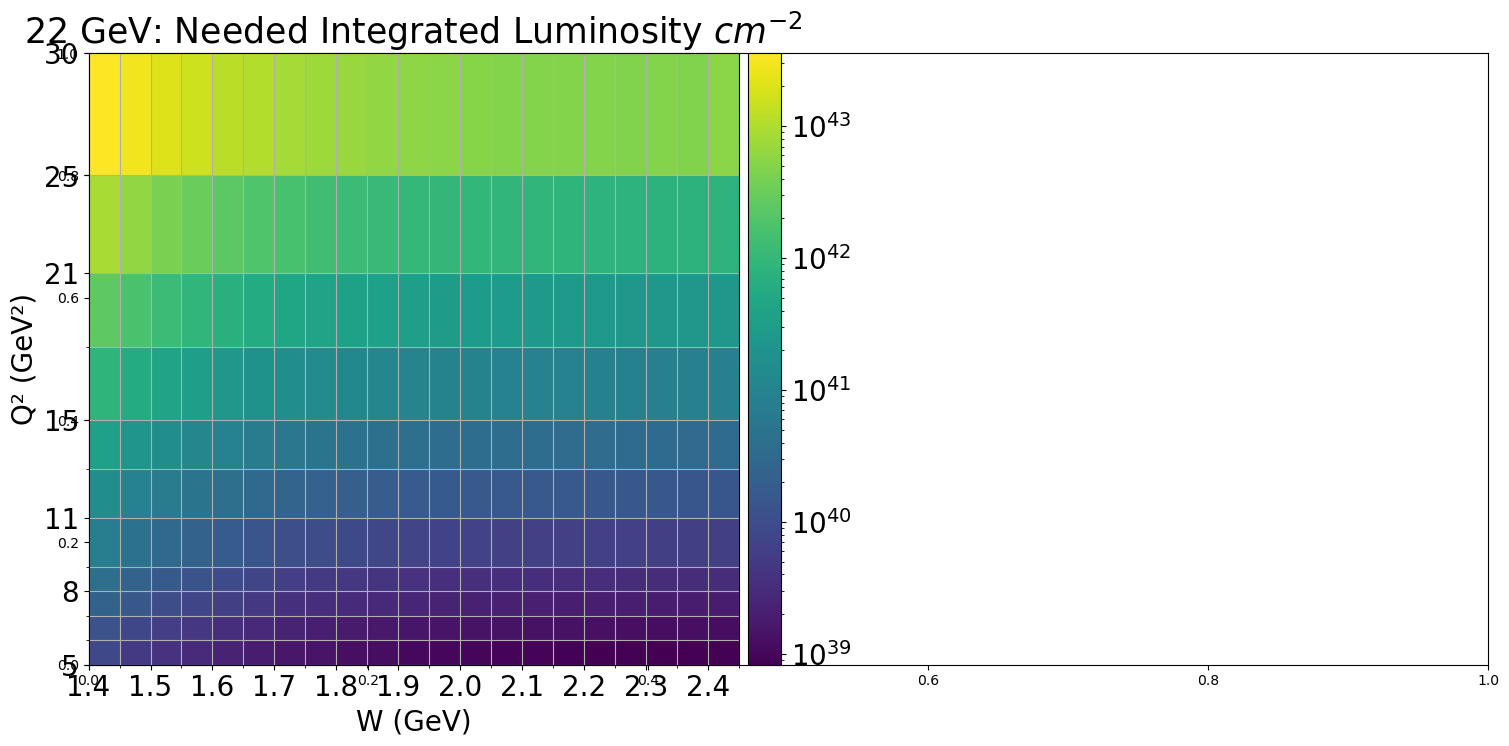

In [21]:
# find integrated luminosity: 22 GeV
from matplotlib.ticker import FormatStrFormatter
fig, ax = plt.subplots(figsize =(15,7))
ax=plt.subplot(1, 2, 1) # row 1, col 2 index 1

# Creating plot
bin_x=np.arange(1.4,2.5, 0.05)
bin_y=[5.0,6.0,7.0,8.0,9.0,11.0,13.0,15.0,18.0,21.0,25.0,30.0]

matplotlib.pyplot.hist2d(hist_22_gev_sim.w_val.to_numpy(),hist_22_gev_sim.q2_val.to_numpy(),
                         bins=[bin_x, bin_y],cmap=plt.cm.get_cmap('viridis'), density=False,
                         cmin =0,norm=mpl.colors.LogNorm(), weights=hist_22_gev_sim.lumi_elec)
  
# show plot
plt.tight_layout() 
ax.set_title('22 GeV: Needed Integrated Luminosity $cm^{-2}$', fontsize=25, color='k')
plt.xlabel('W (GeV)',fontsize=20)
plt.ylabel('Q\N{SUPERSCRIPT TWO} (GeV\N{SUPERSCRIPT TWO})',fontsize=20)

# Adding color bar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.09)
plt.colorbar(cax=cax)
plt.tick_params(labelsize=20);
major_ticks = np.arange(1.4,2.5, 0.1)
minor_ticks = np.arange(1.4,2.5, 0.05)
ax.set_xticks(major_ticks)
ax.set_xticks(minor_ticks, minor=True)
major_ticks = [5.0,8.0,11.0,15.0,21.0,25.0,30.0]
minor_ticks = [5.0,6.0,7.0,8.0,9.0,11.0,13.0,15.0,18.0,21.0,25.0,30.0]
ax.set_yticks(major_ticks)
ax.set_yticks(minor_ticks, minor=True)

# And a corresponding grid
ax.grid(which='both')
ax.tick_params(axis='both', which='major', labelsize=20)

plt.show()

/var/folders/wd/z4b9mvxs2xb0v8hc2svy1l580000gp/T/ipykernel_42609/3443184389.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  bins=[bin_x, bin_y],cmap=plt.cm.get_cmap('viridis'), density=False,


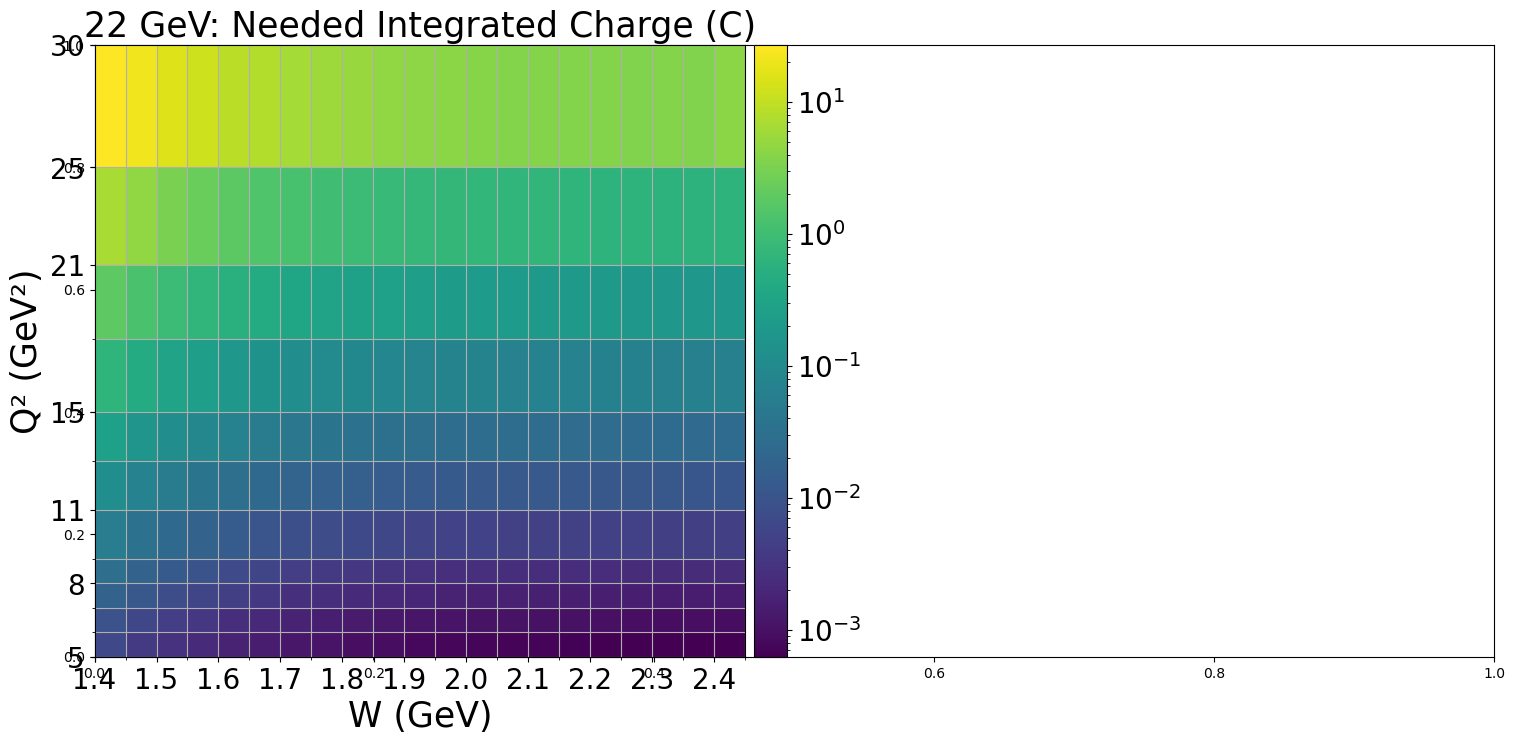

In [22]:
# find integrated charge needed: 22 GeV
from matplotlib.ticker import FormatStrFormatter
fig, ax = plt.subplots(figsize =(15,7))
ax=plt.subplot(1, 2, 1) # row 1, col 2 index 1

# Creating plot
bin_x=np.arange(1.4,2.5, 0.05)
bin_y=[5.0,6.0,7.0,8.0,9.0,11.0,13.0,15.0,18.0,21.0,25.0,30.0]
matplotlib.pyplot.hist2d(hist_22_gev_sim.w_val.to_numpy(),hist_22_gev_sim.q2_val.to_numpy(),
                         bins=[bin_x, bin_y],cmap=plt.cm.get_cmap('viridis'), density=False,
                         cmin =0,norm=mpl.colors.LogNorm(), weights=hist_22_gev_sim.q_elec)
  
# show plot
plt.tight_layout() 
plt.title('22 GeV: Needed Integrated Charge (C)',fontsize=25)
plt.xlabel('W (GeV)',fontsize=25)
plt.ylabel('Q\N{SUPERSCRIPT TWO} (GeV\N{SUPERSCRIPT TWO})',fontsize=25)

# Adding color bar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.09)
plt.colorbar(cax=cax)
plt.tick_params(labelsize=20);
major_ticks = np.arange(1.4,2.5, 0.1)
minor_ticks = np.arange(1.4,2.5, 0.05)
ax.set_xticks(major_ticks)
ax.set_xticks(minor_ticks, minor=True)
major_ticks = [5.0,8.0,11.0,15.0,21.0,25.0,30.0]
minor_ticks = [5.0,6.0,7.0,8.0,9.0,11.0,13.0,15.0,18.0,21.0,25.0,30.0]
ax.set_yticks(major_ticks)
ax.set_yticks(minor_ticks, minor=True)

# And a corresponding grid
ax.grid(which='both')
ax.tick_params(axis='both', which='major', labelsize=20)

plt.show()

/var/folders/wd/z4b9mvxs2xb0v8hc2svy1l580000gp/T/ipykernel_42609/1873796311.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  bins=[bin_x, bin_y],cmap=plt.cm.get_cmap('viridis'), density=False,


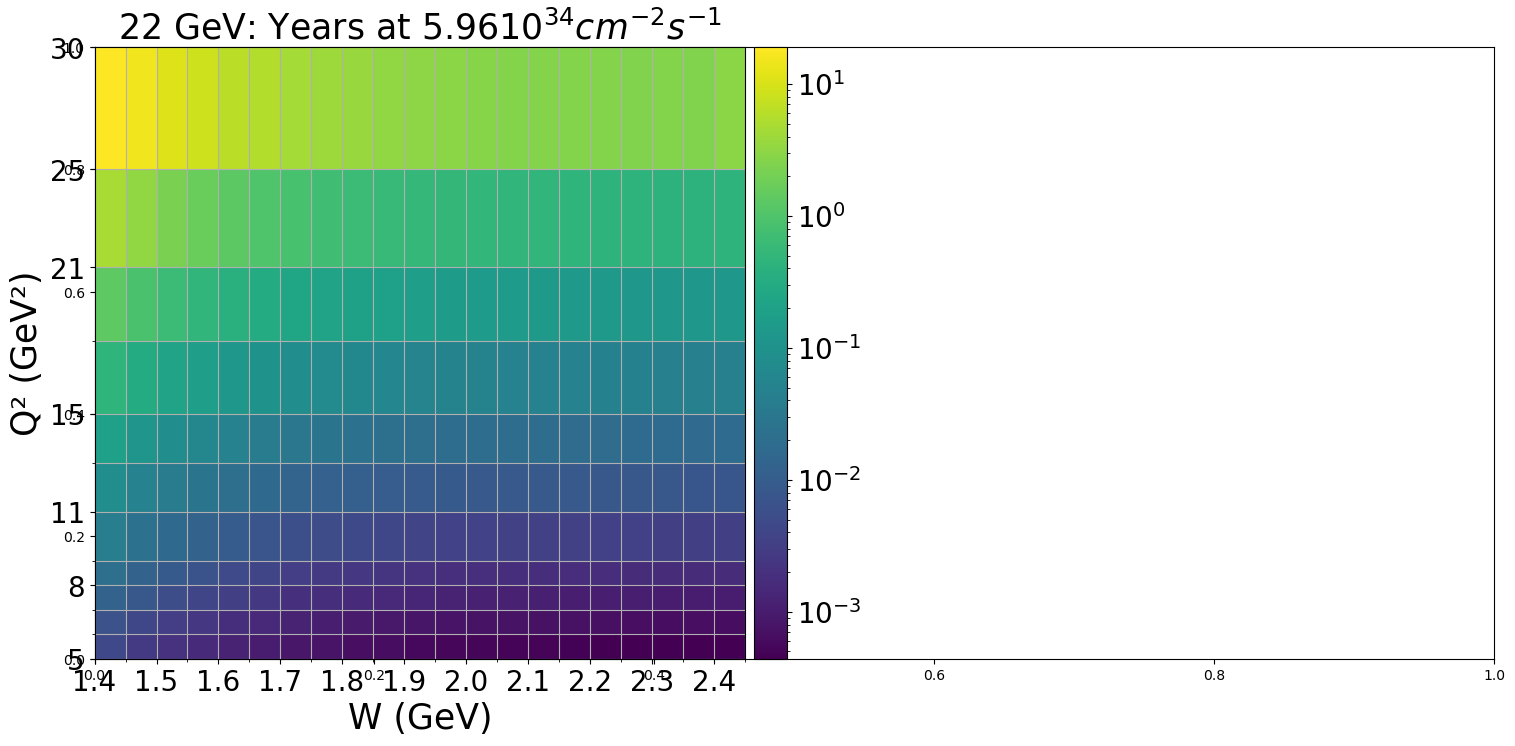

In [23]:
# find time needed in years: 22 GeV
from matplotlib.ticker import FormatStrFormatter
fig, ax = plt.subplots(figsize =(15,7))
ax=plt.subplot(1, 2, 1) # row 1, col 2 index 1

# Creating plot
bin_x=np.arange(1.4,2.5, 0.05)
minor_ticks = [5.0,6.0,7.0,8.0,9.0,11.0,13.0,15.0,18.0,21.0,25.0,30.0]
matplotlib.pyplot.hist2d(hist_22_gev_sim.w_val.to_numpy(),hist_22_gev_sim.q2_val.to_numpy(),
                         bins=[bin_x, bin_y],cmap=plt.cm.get_cmap('viridis'), density=False,
                         cmin =0,norm=mpl.colors.LogNorm(), weights=hist_22_gev_sim.no_year_45nA)
  
# show plot
plt.tight_layout() 
plt.title('22 GeV: Years at $5.96 10^{34} cm^{-2} s^{-1}$',fontsize=25)
plt.xlabel('W (GeV)',fontsize=25)
plt.ylabel('Q\N{SUPERSCRIPT TWO} (GeV\N{SUPERSCRIPT TWO})',fontsize=25)

# Adding color bar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.09)
plt.colorbar(cax=cax)
plt.tick_params(labelsize=20);
major_ticks = np.arange(1.4,2.5, 0.1)
minor_ticks = np.arange(1.4,2.5, 0.05)
ax.set_xticks(major_ticks)
ax.set_xticks(minor_ticks, minor=True)
major_ticks = [5.0,8.0,11.0,15.0,21.0,25.0,30.0]
minor_ticks = [5.0,6.0,7.0,8.0,9.0,11.0,13.0,15.0,18.0,21.0,25.0,30.0]
ax.set_yticks(major_ticks)
ax.set_yticks(minor_ticks, minor=True)

# And a corresponding grid
ax.grid(which='both')
ax.tick_params(axis='both', which='major', labelsize=20)

plt.show()

/var/folders/wd/z4b9mvxs2xb0v8hc2svy1l580000gp/T/ipykernel_42609/3747555849.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  bins=[bin_x, bin_y],cmap=plt.cm.get_cmap('viridis'), density=False,


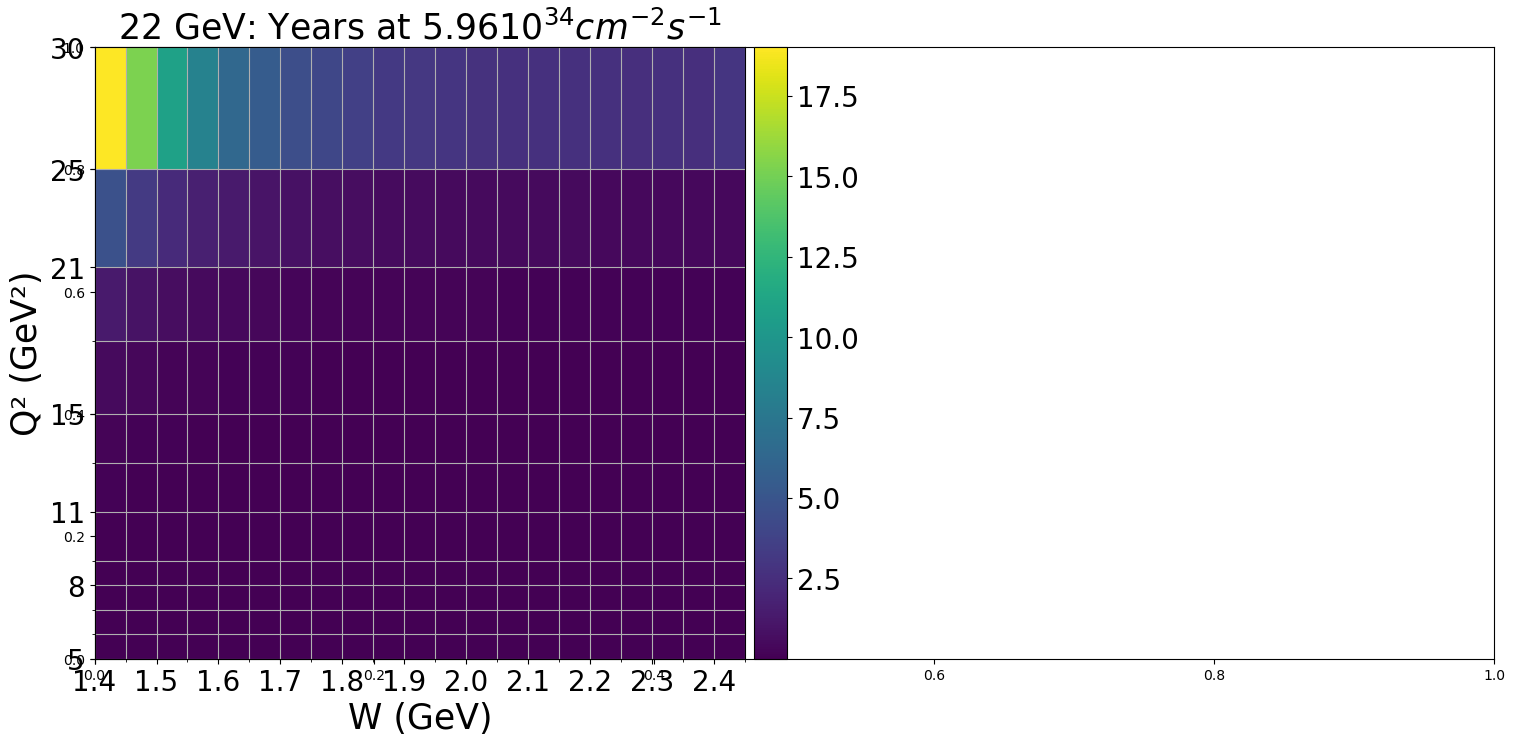

In [24]:
# find time needed in years: 22 GeV
from matplotlib.ticker import FormatStrFormatter
fig, ax = plt.subplots(figsize =(15,7))
ax=plt.subplot(1, 2, 1) # row 1, col 2 index 1

# Creating plot
bin_x=np.arange(1.4,2.5, 0.05)
bin_y=[5.0,6.0,7.0,8.0,9.0,11.0,13.0,15.0,18.0,21.0,25.0,30.0]
matplotlib.pyplot.hist2d(hist_22_gev_sim.w_val.to_numpy(),hist_22_gev_sim.q2_val.to_numpy(),
                         bins=[bin_x, bin_y],cmap=plt.cm.get_cmap('viridis'), density=False,
                         cmin =0, weights=hist_22_gev_sim.no_year_45nA)
  
# show plot
plt.tight_layout() 
plt.title('22 GeV: Years at $5.96 10^{34} cm^{-2} s^{-1}$',fontsize=25)
plt.xlabel('W (GeV)',fontsize=25)
plt.ylabel('Q\N{SUPERSCRIPT TWO} (GeV\N{SUPERSCRIPT TWO})',fontsize=25)

# Adding color bar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.09)
plt.colorbar(cax=cax)
plt.tick_params(labelsize=20);
major_ticks = np.arange(1.4,2.5, 0.1)
minor_ticks = np.arange(1.4,2.5, 0.05)
ax.set_xticks(major_ticks)
ax.set_xticks(minor_ticks, minor=True)
major_ticks = [5.0,8.0,11.0,15.0,21.0,25.0,30.0]
minor_ticks = [5.0,6.0,7.0,8.0,9.0,11.0,13.0,15.0,18.0,21.0,25.0,30.0]
ax.set_yticks(major_ticks)
ax.set_yticks(minor_ticks, minor=True)

# And a corresponding grid
ax.grid(which='both')
ax.tick_params(axis='both', which='major', labelsize=20)

plt.show()